In [ ]:
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
import math
import matplotlib.gridspec as gridspec

In [4]:
%cd .. 

c:\Users\javie\Documents\magister\propagacion-incendios


C:\Users\javie\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
def cambiar_fecha(df):
    df['acq_datetime'] = pd.to_datetime(df['ACQ_DATE'].astype(str) + ' ' + df['ACQ_TIME'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')
    return df


def plot_buffer_viirs(subset):

    # proyectar a metros
    subset2_m = subset.to_crs(epsg=3857)

    # buffer de 187.5 metros
    buffer_m = subset2_m.geometry.buffer(187.5)

    # convertir el buffer de vuelta a lat/lon
    buffer_wgs84 = gpd.GeoSeries(buffer_m, crs=3857).to_crs(epsg=4326)

    subset['pixel_area'] = buffer_wgs84


    ## plot
    pixel_map = subset.set_geometry('pixel_area').explore(
        column='acq_datetime',
        cmap='plasma',
        legend=True,
        tooltip='acq_datetime'
    )

    return subset.explore(
        m=pixel_map,
        color='black',
        marker_kwds={'radius': 2}
    )



### Incendio las maquinas 2017

In [6]:
las_maquinas = gpd.read_file(r'datos-viirs\active_fire\las_maquinas\DL_FIRE_SV-C2_643791\fire_archive_SV-C2_643791.shp')

In [10]:
las_maquinas = cambiar_fecha(las_maquinas)
las_maquinas

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,acq_datetime
0,-35.38191,-72.41774,305.29,0.71,0.75,2017-01-18,0442,N,VIIRS,n,2,288.67,1.27,N,0,POINT (-72.41774 -35.38191),2017-01-18 04:42:00
1,-35.38634,-72.41850,302.98,0.71,0.75,2017-01-18,0442,N,VIIRS,n,2,287.04,1.60,N,0,POINT (-72.4185 -35.38634),2017-01-18 04:42:00
2,-35.37973,-72.41507,301.13,0.71,0.75,2017-01-18,0442,N,VIIRS,n,2,288.60,1.65,N,0,POINT (-72.41507 -35.37973),2017-01-18 04:42:00
3,-35.38440,-72.40975,303.59,0.71,0.75,2017-01-18,0442,N,VIIRS,n,2,289.36,1.27,N,0,POINT (-72.40975 -35.3844),2017-01-18 04:42:00
4,-35.38558,-72.41928,310.09,0.50,0.49,2017-01-18,0622,N,VIIRS,n,2,290.27,13.26,N,0,POINT (-72.41928 -35.38558),2017-01-18 06:22:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11221,-35.19419,-72.06663,325.85,0.40,0.60,2017-02-02,0500,N,VIIRS,n,2,286.67,1.75,N,0,POINT (-72.06663 -35.19419),2017-02-02 05:00:00
11222,-35.34300,-72.34245,297.96,0.41,0.60,2017-02-02,0500,N,VIIRS,n,2,281.02,0.67,N,0,POINT (-72.34245 -35.343),2017-02-02 05:00:00
11223,-35.56423,-72.32401,303.32,0.40,0.60,2017-02-02,0500,N,VIIRS,n,2,283.13,1.29,N,0,POINT (-72.32401 -35.56423),2017-02-02 05:00:00
11224,-35.45658,-72.28250,330.08,0.69,0.74,2017-02-05,1945,N,VIIRS,l,2,302.28,8.19,D,0,POINT (-72.2825 -35.45658),2017-02-05 19:45:00


In [16]:
era5_las_maquinas = gpd.read_file(f'data/procesado/era5/era5_variables_las_maquinas.geojson')

In [18]:
fechas = las_maquinas['acq_datetime'].drop_duplicates().reset_index(drop=True)

In [90]:
fechas_plot = fechas.sort_values().head(30)

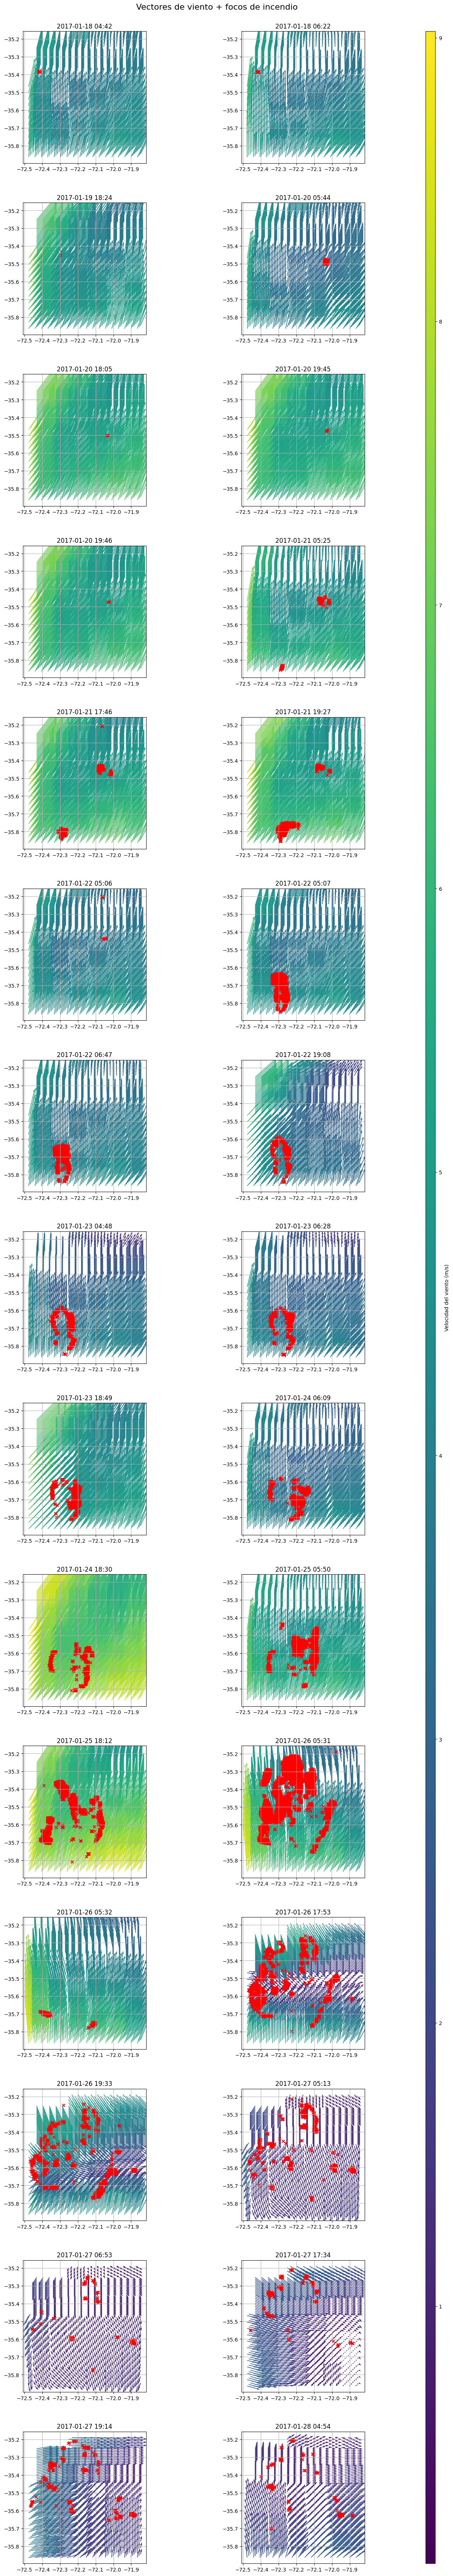

In [ ]:
n = len(fechas_plot)
ncols = 2
nrows = math.ceil(n / ncols)

vmin = era5_las_maquinas['wind_speed'].min()
vmax = era5_las_maquinas['wind_speed'].max()

fig = plt.figure(figsize=(14, nrows * 5))
gs = gridspec.GridSpec(nrows, ncols + 1, width_ratios=[1, 1, 0.05], wspace=0.2)

quiver_plots = []

# Graficar cada fecha
for i, fecha in enumerate(fechas_plot):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col])

    # Filtrar datos
    incendios_df = las_maquinas[las_maquinas['acq_datetime'] == fecha]
    gdf = era5_las_maquinas[era5_las_maquinas['date_time'] == fecha.strftime('%Y-%m-%d %H:00:00')]
    gdf = gdf.iloc[::4, :] ## no se ven las flechas con todos los datos uwu
    
    gdf['lon'] = gdf.geometry.x
    gdf['lat'] = gdf.geometry.y

    # Flechas de viento
    quiv = ax.quiver(
        gdf['lon'], gdf['lat'],
        gdf['u_component_of_wind_10m'], gdf['v_component_of_wind_10m'],
        gdf['wind_speed'], cmap='viridis',
        scale=25, width=0.005, clim=(vmin, vmax)
    )
    quiver_plots.append(quiv)

    # Focos de incendio
    ax.scatter(
        incendios_df['LONGITUDE'], incendios_df['LATITUDE'],
        color='red', marker='x', s=30, label='Focos de incendio'
    )

    ax.set_title(fecha.strftime('%Y-%m-%d %H:%M'))
    ax.set_aspect('equal')
    ax.grid(True)

# colorbar vertical en la ultima columna del GridSpec
cax = fig.add_subplot(gs[:, -1]) 
cbar = fig.colorbar(quiver_plots[0], cax=cax)
cbar.set_label("Velocidad del viento (m/s)")


fig.suptitle("Vectores de viento + focos de incendio", fontsize=16, y=0.98)

fig.subplots_adjust(
    top=0.97,      
    bottom=0.06,  
    left=0.06,
    right=0.92,
    wspace=0.2,
    hspace=0.3    
)
plt.show()

In [92]:
import imageio.v2 as imageio
import os

In [ ]:
output_dir = "gif_frames"
os.makedirs(output_dir, exist_ok=True)

fechas_plot = fechas.sort_values()

vmin = era5_las_maquinas['wind_speed'].min()
vmax = era5_las_maquinas['wind_speed'].max()

filenames = []

for i, fecha in enumerate(fechas_plot):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Filtrar datos
    incendios_df = las_maquinas[las_maquinas['acq_datetime'] == fecha]
    gdf = era5_las_maquinas[era5_las_maquinas['date_time'] == fecha.strftime('%Y-%m-%d %H:00:00')]
    gdf = gdf.iloc[::4, :]  

    gdf['lon'] = gdf.geometry.x
    gdf['lat'] = gdf.geometry.y

    # Viento
    quiv = ax.quiver(
        gdf['lon'], gdf['lat'],
        gdf['u_component_of_wind_10m'], gdf['v_component_of_wind_10m'],
        gdf['wind_speed'],
        cmap='viridis',
        scale=25, width=0.005,
        clim=(vmin, vmax)
    )

    # Focos
    ax.scatter(
        incendios_df['LONGITUDE'], incendios_df['LATITUDE'],
        color='red', marker='x', s=30
    )

    ax.set_title(fecha.strftime('%Y-%m-%d %H:%M'))
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_aspect('equal')
    ax.grid(True)

    # Colorbar
    cbar = fig.colorbar(quiv, ax=ax)
    cbar.set_label("Velocidad del viento (m/s)")

    # Guardar imagen temporal
    filename = f"{output_dir}/frame_{i:02d}.png"
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

    filenames.append(filename)


In [94]:
# gif
with imageio.get_writer("viento_incendios_las_maquinas.gif", mode='I', duration=1000) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)



In [ ]:
### rm imagene guardadas
import shutil
shutil.rmtree(output_dir)

### Incendio Santa Ana